In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

!pip install transformers torch wordninja emoji Sastrawi
import pandas as pd
import numpy as np
import re, wordninja, emoji, torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.1 MB/s eta 0:00:00
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541530 sha256=aded2689a6ffcfe2d2480df5036e6d63057464b366c42fea68261cf06bc7fa1b
  Stored in directory: /root/.cache/pip/wheels/6e/31/92/f12667e4dd102e546832a02f41feca39ae916889006517e595
Successfully built wordninja


***1. Data Understanding***

In [ ]:
data_t = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/External Resource/tweet.csv')
data_t.sample(10)

,Unnamed: 0,sentimen,tweet
411,411,negatif,Karena otakmu... Gak bisa nalar dengan sehat.....
368,368,positif,"Bentar dulu, awalnya narasi elo kan pembanguna..."
24,24,positif,#PilihOrangBaik #PilihJelasIslamnya #PilihBaju...
1239,1239,negatif,Saya simple aja sih... Harga tiket pesawat di ...
1661,1661,negatif,Gaji presiden kurang lebih cuma 65jt... Itu Pr...
671,671,negatif,Ingin semakin sontoloyo aplud jainudin eps bia...
1416,1416,positif,Kreatip nian petani kita. Buat Bpk @Prabowo @...
161,161,netral,Presiden Jokowi dan Raja Salman Sepakat Tingka...
1156,1156,negatif,"gagasan jokowi smlm didebat, soal ekonomi digi..."
1492,1492,positif,Lah jawab dong. Kan ada pertanyaan tuh di atas...


In [ ]:
data_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1815 non-null   int64 
 1   sentimen    1815 non-null   object
 2   tweet       1815 non-null   object
dtypes: int64(1), object(2)
memory usage: 42.7+ KB


**Cek adakah kosong dan duplikat**

In [ ]:
data_t.duplicated().sum()

np.int64(0)

In [ ]:
data_t.isnull().sum()

,0
Unnamed: 0,0
sentimen,0
tweet,0


**Mengambil kolom tweet dan sentimen dan dijadikan dataset data_olah**




In [ ]:
data_olah = data_t[['tweet','sentimen']]

In [ ]:
data_olah.head()

,tweet,sentimen
0,Kata @prabowo Indonesia tidak dihargai bangsa ...,negatif
1,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib...",netral
2,"Di era Jokowi, ekonomi Indonesia semakin baik....",netral
3,"Bagi Sumatera Selatan, Asian Games berdampak p...",positif
4,Negara kita ngutang buat bngun infrastruktur y...,negatif


***Split Antara Testing dan Training***

In [ ]:
from sklearn.model_selection import train_test_split

x_tweet = data_olah['tweet']
y_tweet = data_olah['sentimen']

x_train, x_test, y_train, y_test = train_test_split(
    x_tweet, y_tweet,
    test_size=0.2,
    random_state=42
)

In [ ]:
x_train.shape

(1452,)

In [ ]:
x_test.shape

(363,)

In [ ]:
data_train = pd.DataFrame({'tweet': x_train, 'sentimen': y_train})
data_train

,tweet,sentimen
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral
...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif


In [ ]:
data_test = pd.DataFrame({'tweet': x_test, 'sentimen': y_test})
data_test

,tweet,sentimen
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif
...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral


In [ ]:
data_train['sentimen'].value_counts()

,count
sentimen,
netral,489
positif,482
negatif,481


In [ ]:
data_test['sentimen'].value_counts()

,count
sentimen,
positif,130
netral,118
negatif,115


**Visualisasi Distribusi Label**

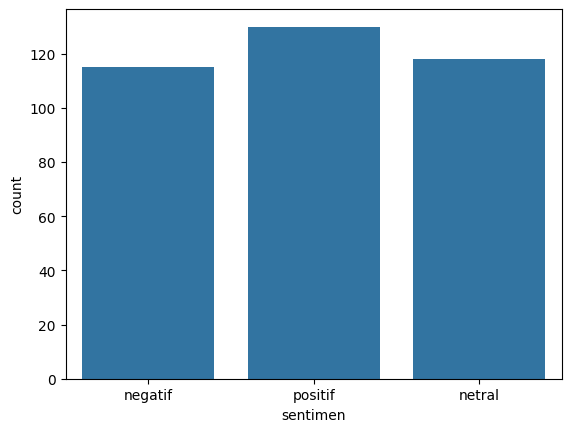

In [ ]:
sns.countplot(x='sentimen', data=data_test)
plt.show()

In [ ]:
data_train

,tweet,sentimen
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral
...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif


In [ ]:
data_test

,tweet,sentimen
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif
...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral


***2. TEXT PROCESSING***

Rencana yang akan dilakukan adalah

```
1 Lowercase
2 Remove URL
3 Remove Mention
4 Remove Hashtag
5 Remove punctuation
6 Remove number
7 Remove weird character
8 Normalisasi
9 Negasi
10 Remove stopwords
11 Stemming
```



In [ ]:
#Inisialisasi Stemmer dan Stopword

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

In [ ]:
# function word ninja
import re, wordninja, emoji, torch
import pandas as pd # Ensure pandas is imported for df_kamus usage
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Path File
#path_dataset = '/content/drive/MyDrive/Colab Project/tweet.csv'
path_kamus = '/content/drive/MyDrive/Colab Notebooks/External Resource/kamuskatabaku.xlsx'

# Load Data
#df_tweet = pd.read_csv(path_dataset)
df_kamus = pd.read_excel(path_kamus)

# Create slang_dict from df_kamus (already loaded in OYUecKFWvyPN)
slang_dict = dict(zip(df_kamus['slang'], df_kamus['formal']))

# Setup Stopwords (Mengecualikan kata Negasi agar sentimen tidak hilang)
factory = StopWordRemoverFactory()
isi_stopwords = factory.get_stop_words()
kata_negasi = ['tidak', 'bukan', 'kurang', 'belum', 'tak', 'ga', 'gak', 'jangan']
final_stopwords = [word for word in isi_stopwords if word not in kata_negasi]

def wordninja_processing(text):
    if not isinstance(text, str): return ""

    # Tangani BPK sebelum lowercase agar tidak tertukar
    # BPK (Uppercase) -> Instansi
    text = re.sub(r'\bBPK\b', 'Badan Pemeriksa Keuangan', text)
    # bpk/Bpk (Mixed/Lower) -> bapak
    text = re.sub(r'\b[Bb]pk\b', 'bapak', text)

    # Normalisasi kata ulang (jalan2 -> jalan-jalan)
    text = re.sub(r'\b(\w+)2\b', r'\1-\1', text)

    # Lowercase setelah BPK ditangani
    text = text.lower()

    # Emoji Handling
    text = emoji.demojize(text).replace(':', ' ')

    # WORDNINJA: Pecah hashtag
    hashtags = re.findall(r'#(\w+)', text)
    for ht in hashtags:
        split_ht = " ".join(wordninja.split(ht))
        text = text.replace(f'#{ht}', split_ht)

    # Hapus URL & Mention
    text = re.sub(r'http\S+|www\S+|@\w+', '', text)

    # NORMALISASI ALAY (Menggunakan Kamus dari Drive)
    words = text.split()
    text = " ".join([slang_dict.get(w, w) for w in words])

    # Bersihkan simbol sisa
    text = re.sub(r'[^a-z\s-]', ' ', text)

    # Stopword Removal (Menjaga Negasi)
    text = " ".join([w for w in text.split() if w not in final_stopwords])

    return text.strip()


In [ ]:
#function cleaning Text

def clean_text_dummy(text):

    text = text.lower()

    # remove url
    text = re.sub(r'http\S+', '', text)

    # remove mention
    text = re.sub(r'@(\w+)', r'\1', text)

    # remove hashtag
    text = re.sub(r'#(\w+)', r'\1', text)

    # remove number
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra whitespace
    text = text.strip()

    return text

In [ ]:
# Proses cleaning
# data_train['clean_tweet'] = data_train['tweet'].apply(clean_text_dummy)

In [ ]:
normalisasi = { "yg": "yang", "dgn": "dengan", "dg": "dengan", "tdk": "tidak", "gk": "tidak"
, "ga": "tidak", "nggak": "tidak", "tak": "tidak", "bkn": "bukan", "krn": "karena"
, "dr": "dari", "dlm": "dalam", "pd": "pada", "utk": "untuk", "jd": "jadi", "jg": "juga"
, "sm": "sama", "sama2": "sama sama", "sy": "saya", "sya": "saya", "gw": "saya", "gue": "saya"
, "aku": "saya", "km": "kamu", "kmu": "kamu", "loe": "kamu", "lu": "kamu", "org": "orang"
, "byk": "banyak", "bnyk": "banyak", "sdh": "sudah", "udh": "sudah", "blm": "belum"
, "hrs": "harus", "hrus": "harus", "bs": "bisa", "bsa": "bisa", "aja": "saja", "doang": "saja"
, "tok": "saja", "nih": "ini", "ni": "ini", "ituu": "itu", "bgt": "banget", "bgtt": "banget"
, "amat": "sangat", "sangattt": "sangat", "tp": "tapi", "tpi": "tapi", "knp": "kenapa", "kpn": "kapan"
, "gmn": "bagaimana", "gmna": "bagaimana", "mn": "mana", "drmn": "darimana", "dimn": "dimana", "kmn": "kemana"
, "pgn": "ingin", "pngen": "ingin", "mau": "ingin", "trs": "terus", "trus": "terus", "udh": "sudah", "lg": "lagi"
, "lgi": "lagi", "skrg": "sekarang", "skrng": "sekarang", "dpt": "dapat", "dapet": "dapat", "ngasih": "memberi"
, "ngasi": "memberi", "ngambil": "mengambil", "ngaku": "mengaku", "ngomong": "berbicara", "ngeliat": "melihat"
, "ngerti": "mengerti", "pke": "pakai", "pkai": "pakai", "pakaii": "pakai", "krja": "kerja", "kerja2": "kerja kerja"
, "rkyat": "rakyat", "indo": "indonesia", "ind": "indonesia", "negri": "negeri"
, "pemrintah": "pemerintah", "presidenya": "presidennya", "pemimpin2": "pemimpin pemimpin"
}

In [ ]:
# Function Normalisasi
def normalize_text(text):

    words = text.split()

    normalized = [normalisasi[word] if word in normalisasi else word for word in words]

    return " ".join(normalized)

In [ ]:
# Menjalankan normalisasi
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(normalize_text)

In [ ]:
# Function Menghilangkan Stopword
# =============================
# 1. Daftar kata negasi
# =============================

negasi = [
    "tidak","bukan","tak","kurang","tdk",
    "gak","ga","gk","nggak","ngga","enggak",
    "belum","jangan"
]


# =============================
# 2. Ambil stopword dari Sastrawi
# =============================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()


# =============================
# 3. Pastikan negasi tidak ada di stopword
# =============================

stopwords = set(stopwords) - set(negasi)


# =============================
# 4. Function Menghilangkan Stopword
# =============================

def remove_stopwords(text):

    # menghindari error jika text kosong
    if not isinstance(text, str):
        return ""

    words = text.split()

    filtered = [word for word in words if word not in stopwords]

    return " ".join(filtered)

In [ ]:
# menjalankan menghilangkan stopword
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(remove_stopwords)

In [ ]:
# Function Stemming
def stemming(text):

    return stemmer.stem(text)

In [ ]:
#menjalankan Stemmming
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(stemming)

In [ ]:
#function Negasi Handling

def handle_negation(text):
    negasi = ["tidak","bukan","gak","ga","nggak","tak","kurang","tdk","enggak","gk","ngga","nda","ndak","jangan","belum"]

    words = text.split()
    result = []
    skip = False

    for i in range(len(words)):
        if skip:
            skip = False
            continue

        if words[i] in negasi and i+1 < len(words):
            result.append(words[i] + "_" + words[i+1])
            skip = True
        else:
            result.append(words[i])

    return " ".join(result)

In [ ]:
# menjalankan menghilangkan Negasi
# data_train['clean_tweet'] = data_train['clean_tweet'].apply(handle_negation)

In [ ]:
# Proses WordNinja
data_train['clean_tweet'] = data_train['tweet'].apply(wordninja_processing)

# Proses cleaning
data_train['clean_tweet'] = data_train['clean_tweet'].apply(clean_text_dummy)

# Menjalankan normalisasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(normalize_text)

# menjalankan menghilangkan stopword
data_train['clean_tweet'] = data_train['clean_tweet'].apply(remove_stopwords)

#menjalankan Stemmming
data_train['clean_tweet'] = data_train['clean_tweet'].apply(stemming)

# menjalankan menghilangkan Negasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(handle_negation)


In [ ]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentar bagus alangkah indshnya ibu bilang jo...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi tumbuh ekonomi syukur jangan_kufur nikm...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat ciwiciwi harga skincare turun tusuk prabo...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillah tutup keren tidak_ambil gaji men...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,utara jokowi kemaren esports sendiri memang be...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah perintah buat hukum enggak_ketat c...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,kata pak benar semua tanggung jawab ulang pak ...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,nama jaman modern gaji transfer bukan_ambil pi...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillah smoga laksana citacita pra bow o...


***Preprocessing data Testing***

In [ ]:
# Proses WordNinja
data_test['clean_tweet'] = data_test['tweet'].apply(wordninja_processing)

# Proses cleaning
data_test['clean_tweet'] = data_test['clean_tweet'].apply(clean_text_dummy)

# Menjalankan normalisasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(normalize_text)

# menjalankan menghilangkan stopword
data_test['clean_tweet'] = data_test['clean_tweet'].apply(remove_stopwords)

#menjalankan Stemmming
data_test['clean_tweet'] = data_test['clean_tweet'].apply(stemming)

# menjalankan menghilangkan Negasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(handle_negation)

In [ ]:
data_test

,tweet,sentimen,clean_tweet
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif,bukan_kurang milenial memang sama sekali engga...
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif,arti presiden tidak_terima gaji prabowo sandi ...
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif,kalau bang bapak mampu tempat mana tugas bangg...
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif,bukan_ekonomi pak hidup buruh korba n ph ki le...
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif,enggak_ngaruh jokowi kutub utara rakyat tau ba...
...,...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif,fyi digital ekonomi papar cawapres laku era pe...
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral,jelas prabowo debat lima sebut soal ekonomi de...
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif,gaji prabowosandi bakal buat kaum yatim dhuafa...
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral,salam bangsa nkri pancasila harga mati sabang ...


***3. Vectorization***

**Random Forest**

***Melakukan encoding untuk data sentimen***

```
negatif = 0
netral = 1
positif = 2
```


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

y_train = data_train['sentimen']
y_train_encode = encoder.fit_transform(y_train)

y_test = data_test['sentimen']
y_test_encode = encoder.transform(y_test)

In [ ]:
y_test_encode

array([0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0,
       0, 1, 1, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2, 2, 1, 0, 2, 1, 1,
       2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 2, 2,
       2, 0, 0, 1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 2, 0, 2, 1, 2,
       2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 2, 1, 2, 2, 2, 2, 1, 0,
       1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 1, 1, 2, 2, 2, 0, 2,
       2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0,
       1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2,
       0, 2, 2, 2, 2, 1, 2, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 2, 2, 0,
       1, 0, 1, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 2, 2, 1,
       2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2,
       2, 1, 2, 0, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2,

***Melakukan TF-IDF***

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True)

Fit pada training data (Fit hanya untuk Training Data)

In [ ]:
x_train_tfidf = tfidf.fit_transform(x_train)

Transform pada Testing data (Test Tidak boleh di fit)

In [ ]:
x_test_tfidf = tfidf.transform(x_test)

In [ ]:
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(1452, 3000)
(363, 3000)


***Training Random Forest***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_train = RandomForestClassifier(
    n_estimators=300,
    random_state=42
    ,class_weight='balanced'
)

***Buat Model***

In [ ]:
rf_train.fit(x_train_tfidf, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

*Prediksi*

In [ ]:
y_pred = rf_train.predict(x_test_tfidf)

***Evaluasi***

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.559228650137741
              precision    recall  f1-score   support

     negatif       0.55      0.67      0.60       115
      netral       0.61      0.55      0.58       118
     positif       0.52      0.47      0.49       130

    accuracy                           0.56       363
   macro avg       0.56      0.56      0.56       363
weighted avg       0.56      0.56      0.56       363

[[77 15 23]
 [20 65 33]
 [43 26 61]]


***Training random Forest + GridSearch***

**Menjalankan Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf_train,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

***Training GridSearch***

In [ ]:
grid_rf.fit(x_train_tfidf, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_weighted', verbose=1)

***Cek Parameter Terbaik***

In [ ]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.6226154865632514


***Menentukan Model terbaik nya***

In [ ]:
best_rf = grid_rf.best_estimator_

***Prediksi Random Forest***

In [ ]:
y_gridsearch_pred = best_rf.predict(x_test_tfidf)

***Evaluasi Model Random Forest***

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_gridsearch_pred))
print(classification_report(y_test, y_gridsearch_pred))
print(confusion_matrix(y_test, y_gridsearch_pred))

Accuracy: 0.5730027548209367
              precision    recall  f1-score   support

     negatif       0.55      0.71      0.62       115
      netral       0.64      0.58      0.61       118
     positif       0.54      0.45      0.49       130

    accuracy                           0.57       363
   macro avg       0.58      0.58      0.57       363
weighted avg       0.58      0.57      0.57       363

[[82 15 18]
 [19 68 31]
 [49 23 58]]




```
Berdasarkan Evaluasi nilai accurasi nya masih sekitar 0.57
```

